In [1]:
#import libraries

import pandas as pd

***
### ==> 1. Data Import and Data Exploration
***

### Datasets
We have 5 csv file 

   - dim_date.csv  
   - dim_hotels.csv
   - dim_rooms.csv
   - fact_aggregated_bookings
   - fact_bookings.csv

**Prompt1:**

I have a CSV file named `fact_bookings.csv` located in the `datasets` folder. How can I read it and store it in a variable called `df_bookings`? Also, I would like to perform a sanity check by displaying the top 5 rows.

**Output**

<img src="outputs/prompt1.png" alt="prompt1" width="500" height="350">

In [3]:
import pandas as pd

# Specify the file path
file_path = 'datasets/fact_bookings.csv'

# Read the CSV file and store it in df_bookings
df_bookings = pd.read_csv(file_path)

# Display the top 5 rows for sanity check
df_bookings.head(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


**Prompt2:**

Could you assist me with these preliminary questions using Pandas code?

1.  How can I determine the number of rows and columns in the `df_bookings` DataFrame?

2.  What are the unique categories present in the `room_category` and `booking_platform` columns of the df_bookings DataFrame?

3.  How can I find the number of rows corresponding to each category in the `booking_platfor`m column of the df_bookings DataFrame? Additionally, could you assist me in creating a bar chart to visualize this information effectively?

**Output**
<img src="outputs/prompt2_1.png" alt="prompt2_1" width="500" height="350">
<img src="outputs/prompt2_2.png" alt="prompt2_2" width="500" height="350">

Number of rows: 134590
Number of columns: 12
********************
Unique room categories: ['RT1' 'RT2' 'RT3' 'RT4']
Unique booking platforms: ['direct online' 'others' 'logtrip' 'tripster' 'makeyourtrip' 'journey'
 'direct offline']
********************


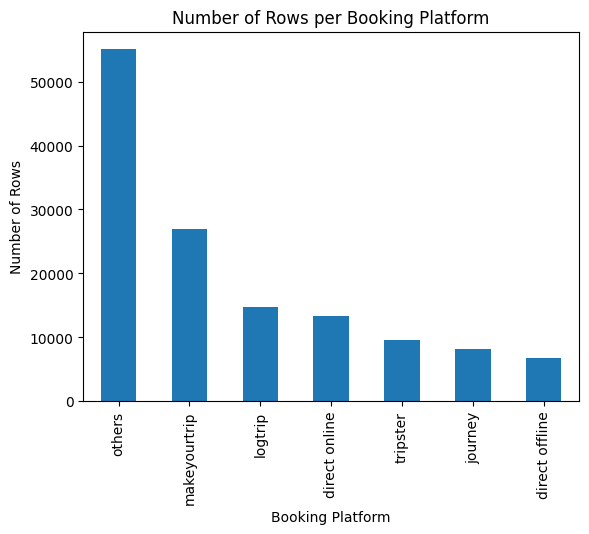

In [10]:
#How can I determine the number of rows and columns in the df_bookings DataFrame?

num_rows = df_bookings.shape[0]
num_columns = df_bookings.shape[1]
print("Number of rows:", num_rows)
print("Number of columns:", num_columns)

print('*' * 20)

#What are the unique categories present in the room_category and booking_platform columns of the df_bookings DataFrame?
unique_room_categories = df_bookings['room_category'].unique()
unique_booking_platforms = df_bookings['booking_platform'].unique()
print("Unique room categories:", unique_room_categories)
print("Unique booking platforms:", unique_booking_platforms)

print('*' * 20)

#How can I find the number of rows corresponding to each category in the booking_platform column of the 
#df_bookings DataFrame? Additionally, could you assist me in creating a bar chart to visualize this information effectively?

import matplotlib.pyplot as plt

booking_platform_counts = df_bookings['booking_platform'].value_counts()
booking_platform_counts.plot(kind='bar')
plt.xlabel('Booking Platform')
plt.ylabel('Number of Rows')
plt.title('Number of Rows per Booking Platform')
plt.show()


**Read rest of the files**

In [4]:
df_date = pd.read_csv('datasets/dim_date.csv')
df_hotels = pd.read_csv('datasets/dim_hotels.csv')
df_rooms = pd.read_csv('datasets/dim_rooms.csv')
df_agg_bookings = pd.read_csv('datasets/fact_aggregated_bookings.csv')

***
### ==> 2. Data Cleaning
***

**(1) Clean invalid guests**

In [5]:
#sanity check
df_bookings[df_bookings.no_guests<=0].head(3)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900


**Prompt3:**


How can I remove the invalid guests (those containing 0 or less than 0) from the `no_guests` column in the `df_bookings` DataFrame and update the same DataFrame with the cleaned data?

**Output**

<img src="outputs/prompt3.png" alt="prompt3" width="500" height="350">

In [6]:

#clean `guest` column
df_bookings = df_bookings[df_bookings['no_guests'] > 0]

print(df_bookings.shape)

(134578, 12)


**(2) Outlier removal in revenue generated**

**Prompt4:**

How can I filter the data in the `df_bookings` DataFrame based on the `revenue_generated` column, keeping only the data that falls within 3 standard deviations from the mean, and update the same DataFrame with the cleaned data?

**Output**

<img src="outputs/prompt4.png" alt="prompt4" width="500" height="350">

In [7]:
#data within 3 standard deviation

mean = df_bookings['revenue_generated'].mean()
std = df_bookings['revenue_generated'].std()
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

df_bookings = df_bookings[(df_bookings['revenue_generated'] >= lower_bound) & (df_bookings['revenue_generated'] <= upper_bound)]

print(df_bookings.shape)

(134573, 12)


**(3) In df_agg_bookings dataframe, find out records that have 'successful_bookings' value greater than 'capacity'. Filter those records**

**Prompt5:**

How can I filter the data in the `df_agg_bookings` dataframe where the value of `successful_bookings` is less than equal to the `capacity` and update the same DataFrame with the cleaned data?

**Output**

<img src="outputs/prompt5.png" alt="prompt4" width="500" height="350">

In [8]:
df_agg_bookings = df_agg_bookings[df_agg_bookings['successful_bookings'] <= df_agg_bookings['capacity']]

print(df_agg_bookings.shape)

(9192, 5)


***
### ==> 3. Data Transformation
***

There are various types of data transformations that you may have to perform based on the need. Few examples of data transformations are,

1. Creating new columns
1. Normalization
1. Merging data
1. Aggregation

**(1) Create occupancy percentage column**

**Prompt6:**

How to create a new column named `occ_pct` in the `df_agg_bookings` dataframe? This new column should contain the ratio of `successful_bookings` to `capacity`, represented as a percentage with two decimal values.

**Output**

<img src="outputs/prompt6.png" alt="prompt4" width="500" height="350">

In [9]:
df_agg_bookings['occ_pct'] = (df_agg_bookings['successful_bookings'] / df_agg_bookings['capacity'] * 100).round(2)

df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
4,16558,1-May-22,RT1,18,19.0,94.74
5,17560,1-May-22,RT1,28,40.0,70.00


***
### ==> 4. Insights Generation
***

**1. When was the occupancy better? Weekday or Weekend?**

In [10]:
df_date.head(2)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday


In [11]:
df_agg_bookings.head(2)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33


**Prompt7:**


How to do the below scenario in Pandas?

- I have two dataframes: `df_date` and `df_agg_bookings`. The df_date dataframe has columns for date, mmm yy, week no, and day_type. The df_agg_bookings dataframe has columns for property_id, check_in_date, room_category, successful_bookings, capacity, and occ_pct. Note that the 'day_type' column in df_date contains two categories that indicate whether a specific date is a weekday or a weekend. I want to find out  the occupancy pattern between `weekdays` and `weekends`. 

- Also, create appropriate chart for the output data. 

**Output**

<img src="outputs/prompt7_2.png" alt="prompt7" width="500" height="350">

day_type
weekeday    50.883140
weekend     72.343625
Name: occ_pct, dtype: float64


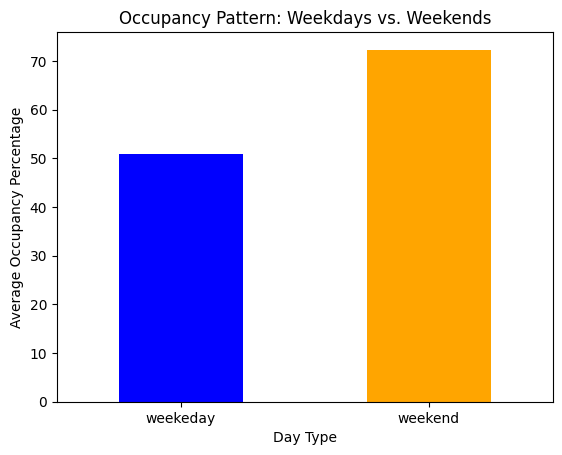

In [12]:
#merging
merged_df = df_date.merge(df_agg_bookings, left_on='date', right_on='check_in_date')


#avg occupancy
occupancy_pattern = merged_df.groupby('day_type')['occ_pct'].mean()
print(occupancy_pattern)

#plot the chart
import matplotlib.pyplot as plt

# Create a bar chart
occupancy_pattern.plot(kind='bar', color=['blue', 'orange'])
plt.xlabel('Day Type')
plt.ylabel('Average Occupancy Percentage')
plt.title('Occupancy Pattern: Weekdays vs. Weekends')
plt.xticks(rotation=0)
plt.show()


**Insight:**
- The average occupancy percentage is higher on `weekends` (72.34%) compared to `weekdays` (50.88%). This suggests that the property experiences higher occupancy levels during weekends, potentially indicating higher demand or different customer behavior on weekends compared to weekdays. This insight can be valuable for making business decisions and optimizing operations, such as staffing and pricing strategies, to better accommodate the occupancy patterns and maximize revenue.

**2. Booking platform Vs Revenue Realized**

In [13]:
df_bookings.head(2)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


**Prompt8:**


How to do the below scenario in Pandas?

- I have a dataframe named df_bookings with columns such as booking_id, property_id, booking_date, check_in_date, checkout_date, no_guests, room_category, booking_platform, ratings_given, booking_status, revenue_generated, and revenue_realized. My objective is to group the data by booking_platform and analyze the revenue generated by each platform. Additionally, I would like to create an appropriate chart to visualize the output data. 

**Output**

<img src="outputs/prompt8.png" alt="prompt7" width="500" height="350">

booking_platform
direct offline    101329855
direct online     198683560
journey           120654715
logtrip           219418495
makeyourtrip      401476330
others            821007990
tripster          144714510
Name: revenue_generated, dtype: int64


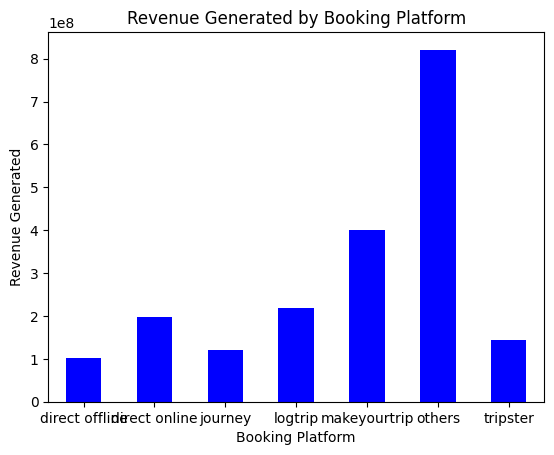

In [16]:
#group by revenue
revenue_by_platform = df_bookings.groupby('booking_platform')['revenue_generated'].sum()
print(revenue_by_platform)

#plot
import matplotlib.pyplot as plt

# Create a bar chart
revenue_by_platform.plot(kind='bar', color='blue')
plt.xlabel('Booking Platform')
plt.ylabel('Revenue Generated')
plt.title('Revenue Generated by Booking Platform')
plt.xticks(rotation=0)
plt.show()


**Note:** 

- The previously provided code by ChatGPT may require further customization to enhance its visual appeal in this context.

**updated prompt:**
- The above code for plotting is not that great. can you customize it to increase the visual appeal?

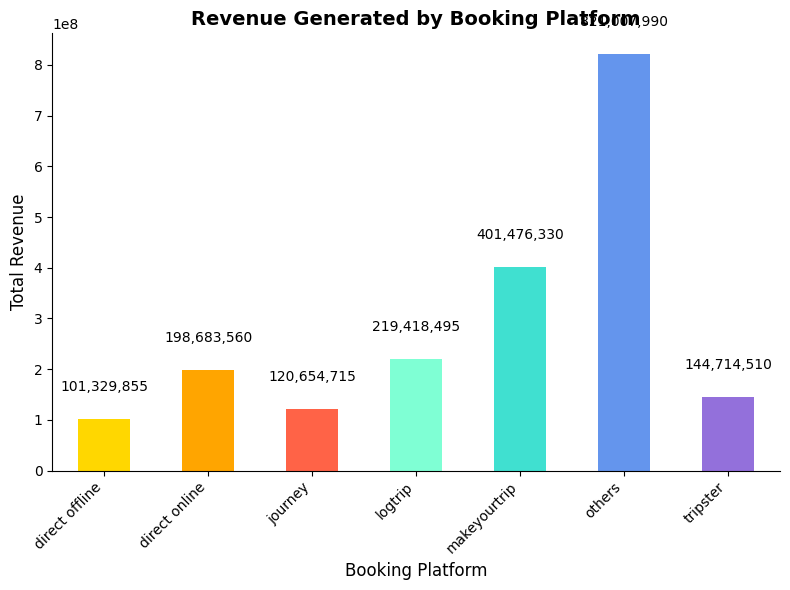

In [17]:
import matplotlib.pyplot as plt

# Set the color palette for the chart
colors = ['#FFD700', '#FFA500', '#FF6347', '#7FFFD4', '#40E0D0', '#6495ED', '#9370DB']

# Create a figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Create a bar chart with custom colors
revenue_by_platform.plot(kind='bar', color=colors, ax=ax)

# Set the title and labels
ax.set_title('Revenue Generated by Booking Platform', fontsize=14, fontweight='bold')
ax.set_xlabel('Booking Platform', fontsize=12)
ax.set_ylabel('Total Revenue', fontsize=12)

# Customize the tick labels and rotation
ax.set_xticklabels(revenue_by_platform.index, rotation=45, ha='right', fontsize=10)

# Add data labels to the bars
for i, v in enumerate(revenue_by_platform):
    ax.text(i, v + 50000000, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()


**Insight:**
- A key insight is that the booking platform `others` has the highest total revenue of 821,007,990. This suggests that the "others" platform contributes significantly to the overall revenue generated. It may be worth further analysis to understand the specific nature of this platform and explore potential strategies to capitalize on its success. 
- Additionally, the platforms `makeyourtrip` and `logtrip` also demonstrate substantial revenue, with totals of 401,476,330 and 219,418,495, respectively. This insight can guide decision-making and resource allocation, allowing businesses to focus on maximizing revenue from these high-performing platforms while also identifying potential growth opportunities.

